# Notebook 29 — Lithium Plating Stage 1 Stress-State Audit

## Goal

Audit the Stage 1 process-isolated lithium-plating stress-state generation outputs.

This notebook does not run PyBaMM simulations.

It reads completed Stage 1 documentation tables and checks whether the process-isolated stress runner produced a clean model-internal plating stress matrix.

## Scientific context

Notebook 28 established the design contract for lithium-plating external diagnostic closure.

The Stage 1 script:

- `scripts/run_plating_external_stress_condition.py`

was then used to generate matched stress-state outputs for:

- 25 °C / 1C
- 10 °C / 1C
- 10 °C / 2C

Each matched pair contains:

- one no-plating control
- one plating-enabled branch

The purpose of Notebook 29 is to audit whether Stage 1 cleanly supports Level 0 evidence:

> model-internal lithium-plating state observability across matched stress conditions.

## Protocol / study design

This notebook reads the compact Stage 1 matched-check tables:

- `docs/tables/plating_external_stage1_all_pairs_stress_summary_matched_check.csv`
- `docs/tables/plating_external_stage1_all_pairs_direct_plating_matched_check.csv`

It audits:

1. matched-pair protocol consistency
2. no-plating control cleanliness
3. stress-dependent internal plating response
4. maximum internal plating response versus final residual plating signal
5. interpretation boundary for external diagnostic closure

## Workflow

1. Audit repository state and input files.
2. Load Stage 1 matched-check tables.
3. Plot stress-summary matched differences.
4. Plot maximum plating capacity versus stress condition.
5. Plot plating current density versus stress condition.
6. Compare maximum internal plating response with final residual.
7. Save documentation-ready figures and summary tables.
8. Close with supported, partially supported, unsupported, and deferred claims.

## Expected outputs

Expected documentation figures:

- `docs/figures/plating_stage1_max_plating_capacity_by_stress.png`
- `docs/figures/plating_stage1_plating_current_density_by_stress.png`
- `docs/figures/plating_stage1_max_vs_final_residual.png`
- `docs/figures/plating_stage1_matched_protocol_delta.png`

Expected documentation tables:

- `docs/tables/plating_stage1_level0_summary_v0_1.csv`

## Interpretation boundary

This notebook can support Level 0 evidence only:

- model-internal plating-state observability
- clean no-plating matched controls
- stress-dependent internal plating response

This notebook cannot support:

- external diagnostic fingerprint closure
- C/25 V(Q) diagnostic validity
- GITT-like finite-rest voltage validity
- ICA / DVA fitting-target qualification
- Level 1, Level 2, or Level 3 plating claims

External diagnostic closure remains deferred to later notebooks.

In [1]:
# Cell 2 — Environment and repository audit（环境与仓库状态审计）

from pathlib import Path
import sys
import subprocess
import platform

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd()
expected_repo_name = "pybamm-aging-bridge"

if cwd.name == expected_repo_name:
    repo = cwd
elif cwd.name == "notebooks" and cwd.parent.name == expected_repo_name:
    repo = cwd.parent
else:
    repo = cwd

print("[ENV] Python executable:")
print(sys.executable)

print("\n[ENV] Python version:")
print(sys.version)

print("\n[ENV] Platform:")
print(platform.platform())

print("\n[PATH] Notebook current working directory:")
print(cwd)

print("\n[PATH] Resolved repository root:")
print(repo)

if repo.name != expected_repo_name:
    print(f"[WARNING] Resolved repo name is '{repo.name}', expected '{expected_repo_name}'.")
else:
    print(f"[OK] Repository root resolved correctly: {repo}")

print("\n[GIT] status:")
git_status = subprocess.run(
    ["git", "status", "--short"],
    cwd=repo,
    capture_output=True,
    text=True,
)
print(git_status.stdout if git_status.stdout.strip() else "[OK] working tree clean")

print("\n[GIT] recent commits:")
git_log = subprocess.run(
    ["git", "log", "--oneline", "--max-count=8"],
    cwd=repo,
    capture_output=True,
    text=True,
)
print(git_log.stdout)

docs_table_dir = repo / "docs" / "tables"
docs_fig_dir = repo / "docs" / "figures"
data_dir = repo / "data"

for path in [docs_table_dir, docs_fig_dir, data_dir]:
    path.mkdir(parents=True, exist_ok=True)
    print(f"[OK] ensured directory: {path}")

stress_summary_path = docs_table_dir / "plating_external_stage1_all_pairs_stress_summary_matched_check.csv"
direct_plating_path = docs_table_dir / "plating_external_stage1_all_pairs_direct_plating_matched_check.csv"

required_inputs = [stress_summary_path, direct_plating_path]
missing_inputs = [p for p in required_inputs if not p.exists()]

if missing_inputs:
    print("\n[WARNING] Missing input files:")
    for p in missing_inputs:
        print("-", p)
else:
    print("\n[OK] Required Stage 1 input files exist:")
    for p in required_inputs:
        print("-", p.relative_to(repo))

print("\n[BOUNDARY] Notebook execution boundary:")
print("[OK] This notebook reads Stage 1 CSV outputs only.")
print("[OK] No PyBaMM simulation is executed here.")
print("[OK] This notebook audits Level 0 model-internal plating evidence only.")

assert repo.name == expected_repo_name, "Repository root was not resolved correctly."
assert not missing_inputs, "Required Stage 1 input files are missing."

print("\n[OK] Environment and input-file audit completed.")

[ENV] Python executable:
/Users/louislu/projects/pybamm-aging-bridge/.venv/bin/python

[ENV] Python version:
3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 21.0.0 (clang-2100.0.123.102)]

[ENV] Platform:
macOS-26.3.1-arm64-arm-64bit

[PATH] Notebook current working directory:
/Users/louislu/projects/pybamm-aging-bridge/notebooks

[PATH] Resolved repository root:
/Users/louislu/projects/pybamm-aging-bridge
[OK] Repository root resolved correctly: /Users/louislu/projects/pybamm-aging-bridge

[GIT] status:
?? notebooks/29_lithium_plating_stage1_stress_state_audit.ipynb


[GIT] recent commits:
dbc7f47 chore: ignore local plating external stage1 outputs
fa72038 feat: add process-isolated plating external stress runner
8d782b7 chore: clean repository-safe wording in synthesis notebook
dea61dd docs: add lithium plating external diagnostic closure contract
1f95794 Update README.md
447af1a docs: refactor README to v0.1 release entry, add MIT License
20944b4 chore: pin requirements, refresh v0.1 h

## 1. Stage 1 data loading and integrity audit（Stage 1 数据读取与完整性审计）

This block loads the Stage 1 matched-check tables and verifies that the expected matched pairs and model-internal plating variables are present.

The audit checks:

- all three matched pairs are present
- no-plating controls remain zero / near-zero
- plating-enabled branches contain non-zero model-internal plating variables
- stress-dependent plating capacity and current-density features are available

This is still a Level 0 audit. It does not evaluate external diagnostic fingerprints.

In [2]:
# Cell 4 — Load and audit Stage 1 matched-check tables（读取并审计 Stage 1 匹配对照表）

stress_summary_df = pd.read_csv(stress_summary_path)
direct_plating_df = pd.read_csv(direct_plating_path)

print("[OK] Loaded Stage 1 stress summary matched-check table:")
print(stress_summary_path.relative_to(repo))
print(stress_summary_df.shape)

print("\n[OK] Loaded Stage 1 direct plating matched-check table:")
print(direct_plating_path.relative_to(repo))
print(direct_plating_df.shape)

print("\n[Stage 1 stress summary matched-check table]")
display(stress_summary_df)

print("\n[Stage 1 direct plating matched-check table]")
display(direct_plating_df)

expected_pairs = {
    "pair_25C_1C",
    "pair_10C_1C",
    "pair_10C_2C",
}

observed_pairs_stress = set(stress_summary_df["matched_pair_id"].unique())
observed_pairs_direct = set(direct_plating_df["matched_pair_id"].unique())

assert expected_pairs == observed_pairs_stress, (
    f"Stress summary pairs mismatch: expected {expected_pairs}, observed {observed_pairs_stress}"
)

assert expected_pairs == observed_pairs_direct, (
    f"Direct plating pairs mismatch: expected {expected_pairs}, observed {observed_pairs_direct}"
)

required_stress_metrics = {
    "duration_min",
    "charge_Ah",
    "discharge_Ah",
    "throughput_Ah",
    "net_charge_Ah",
    "U_end_V",
}

observed_stress_metrics = set(stress_summary_df["metric"].unique())
missing_stress_metrics = required_stress_metrics - observed_stress_metrics

assert not missing_stress_metrics, (
    f"Missing required stress summary metrics: {missing_stress_metrics}"
)

capacity_var = "Loss of capacity to negative lithium plating [A.h]"
xavg_current_var = "X-averaged negative electrode lithium plating interfacial current density [A.m-2]"

assert capacity_var in set(direct_plating_df["variable_name"]), (
    "Direct plating capacity variable missing from matched-check table."
)

assert xavg_current_var in set(direct_plating_df["variable_name"]), (
    "X-averaged plating current-density variable missing from matched-check table."
)

# Extract compact Level 0 summary variables
capacity_summary_df = (
    direct_plating_df[direct_plating_df["variable_name"] == capacity_var]
    .copy()
    .sort_values("matched_pair_id")
)

xavg_current_summary_df = (
    direct_plating_df[direct_plating_df["variable_name"] == xavg_current_var]
    .copy()
    .sort_values("matched_pair_id")
)

print("\n[OK] Direct plating capacity summary:")
display(capacity_summary_df)

print("\n[OK] X-averaged plating current-density summary:")
display(xavg_current_summary_df)

# Clean-control checks
assert (capacity_summary_df["control_max_abs"] == 0).all(), (
    "No-plating controls must have zero direct plating capacity."
)

assert (xavg_current_summary_df["control_max_abs"] == 0).all(), (
    "No-plating controls must have zero x-averaged plating current density."
)

assert (capacity_summary_df["plating_max_abs"] > 0).all(), (
    "Plating-enabled branches must have non-zero plating capacity signal."
)

assert (xavg_current_summary_df["plating_max_abs"] > 0).all(), (
    "Plating-enabled branches must have non-zero x-averaged plating current-density signal."
)

print("\n[BOUNDARY CHECKS]")
print("[OK] All expected matched pairs are present.")
print("[OK] Required stress-summary metrics are present.")
print("[OK] No-plating controls remain zero for direct plating capacity and x-averaged plating current density.")
print("[OK] Plating-enabled branches show non-zero model-internal plating variables.")
print("[OK] This supports Level 0 evidence only; external diagnostic closure remains untested.")

[OK] Loaded Stage 1 stress summary matched-check table:
docs/tables/plating_external_stage1_all_pairs_stress_summary_matched_check.csv
(18, 5)

[OK] Loaded Stage 1 direct plating matched-check table:
docs/tables/plating_external_stage1_all_pairs_direct_plating_matched_check.csv
(30, 9)

[Stage 1 stress summary matched-check table]


,matched_pair_id,metric,control_value,plating_value,plating_minus_control
0,pair_25C_1C,duration_min,396.636077,396.188655,-4.474214e-01
1,pair_25C_1C,charge_Ah,4.783172,4.780597,-2.574948e-03
2,pair_25C_1C,discharge_Ah,4.978101,4.975338,-2.762808e-03
3,pair_25C_1C,throughput_Ah,9.761273,9.755935,-5.337756e-03
4,pair_25C_1C,net_charge_Ah,-0.194929,-0.194741,1.878599e-04
5,pair_25C_1C,U_end_V,2.768019,2.768019,2.734041e-07
6,pair_10C_1C,duration_min,420.258503,419.000766,-1.257736e+00
7,pair_10C_1C,charge_Ah,4.725713,4.718561,-7.151307e-03
8,pair_10C_1C,discharge_Ah,4.880210,4.872680,-7.529941e-03
9,pair_10C_1C,throughput_Ah,9.605923,9.591241,-1.468125e-02



[Stage 1 direct plating matched-check table]


,matched_pair_id,variable_name,control_max_abs,plating_max_abs,plating_minus_control_max_abs,plating_final_value,control_final_value,plating_signal_status,control_signal_status
0,pair_25C_1C,Loss of capacity to negative lithium plating [...,0.0,4.452329e-02,4.452329e-02,1.872488e-04,0.0,nonzero_internal_plating_variable_detected,available_but_zero_or_near_zero
1,pair_25C_1C,Loss of lithium to negative lithium plating [mol],0.0,1.661225e-03,1.661225e-03,6.986508e-06,0.0,nonzero_internal_plating_variable_detected,available_but_zero_or_near_zero
2,pair_25C_1C,X-averaged negative lithium plating concentrat...,0.0,1.895569e+02,1.895569e+02,-3.106930e-03,0.0,nonzero_internal_plating_variable_detected,available_but_zero_or_near_zero
3,pair_25C_1C,X-averaged negative dead lithium concentration...,0.0,8.015713e-01,8.015713e-01,8.015613e-01,0.0,nonzero_internal_plating_variable_detected,available_but_zero_or_near_zero
4,pair_25C_1C,X-averaged negative lithium plating thickness [m],0.0,6.417974e-09,6.417974e-09,-1.051938e-13,0.0,nonzero_internal_plating_variable_detected,available_but_zero_or_near_zero
5,pair_25C_1C,X-averaged negative dead lithium thickness [m],0.0,2.713942e-11,2.713942e-11,2.713908e-11,0.0,nonzero_internal_plating_variable_detected,available_but_zero_or_near_zero
6,pair_25C_1C,X-averaged negative electrode lithium plating ...,0.0,3.097434e-02,3.097434e-02,-3.248450e-11,0.0,nonzero_internal_plating_variable_detected,available_but_zero_or_near_zero
7,pair_25C_1C,X-averaged negative electrode lithium plating ...,0.0,1.064930e+00,1.064930e+00,8.451324e-01,0.0,nonzero_internal_plating_variable_detected,available_but_zero_or_near_zero
8,pair_25C_1C,Negative electrode lithium plating interfacial...,0.0,8.891850e-02,8.891850e-02,-3.248450e-11,0.0,nonzero_internal_plating_variable_detected,available_but_zero_or_near_zero
9,pair_25C_1C,Negative electrode lithium plating reaction ov...,0.0,1.074441e+00,1.074441e+00,8.451324e-01,0.0,nonzero_internal_plating_variable_detected,available_but_zero_or_near_zero



[OK] Direct plating capacity summary:


,matched_pair_id,variable_name,control_max_abs,plating_max_abs,plating_minus_control_max_abs,plating_final_value,control_final_value,plating_signal_status,control_signal_status
10,pair_10C_1C,Loss of capacity to negative lithium plating [...,0.0,0.072795,0.072795,0.000386,0.0,nonzero_internal_plating_variable_detected,available_but_zero_or_near_zero
20,pair_10C_2C,Loss of capacity to negative lithium plating [...,0.0,0.095446,0.095446,0.000518,0.0,nonzero_internal_plating_variable_detected,available_but_zero_or_near_zero
0,pair_25C_1C,Loss of capacity to negative lithium plating [...,0.0,0.044523,0.044523,0.000187,0.0,nonzero_internal_plating_variable_detected,available_but_zero_or_near_zero



[OK] X-averaged plating current-density summary:


,matched_pair_id,variable_name,control_max_abs,plating_max_abs,plating_minus_control_max_abs,plating_final_value,control_final_value,plating_signal_status,control_signal_status
16,pair_10C_1C,X-averaged negative electrode lithium plating ...,0.0,0.057522,0.057522,2.255052e-09,0.0,nonzero_internal_plating_variable_detected,available_but_zero_or_near_zero
26,pair_10C_2C,X-averaged negative electrode lithium plating ...,0.0,0.138783,0.138783,-6.172627e-10,0.0,nonzero_internal_plating_variable_detected,available_but_zero_or_near_zero
6,pair_25C_1C,X-averaged negative electrode lithium plating ...,0.0,0.030974,0.030974,-3.248450e-11,0.0,nonzero_internal_plating_variable_detected,available_but_zero_or_near_zero



[BOUNDARY CHECKS]
[OK] All expected matched pairs are present.
[OK] Required stress-summary metrics are present.
[OK] No-plating controls remain zero for direct plating capacity and x-averaged plating current density.
[OK] Plating-enabled branches show non-zero model-internal plating variables.
[OK] This supports Level 0 evidence only; external diagnostic closure remains untested.


## 2. Stress-dependent model-internal plating response（应力相关模型内部析锂响应）

This block visualizes whether the model-internal plating response increases with stress severity.

The stress order is:

1. 25 °C / 1C
2. 10 °C / 1C
3. 10 °C / 2C

Two model-internal indicators are audited:

- maximum loss of capacity to negative lithium plating
- maximum X-averaged negative-electrode plating interfacial current density

These variables are model-internal plating-state descriptors. They are not measurement-accessible external diagnostic fingerprints.

The goal is to check whether Stage 1 cleanly reproduces the expected stress-dependent internal plating matrix.

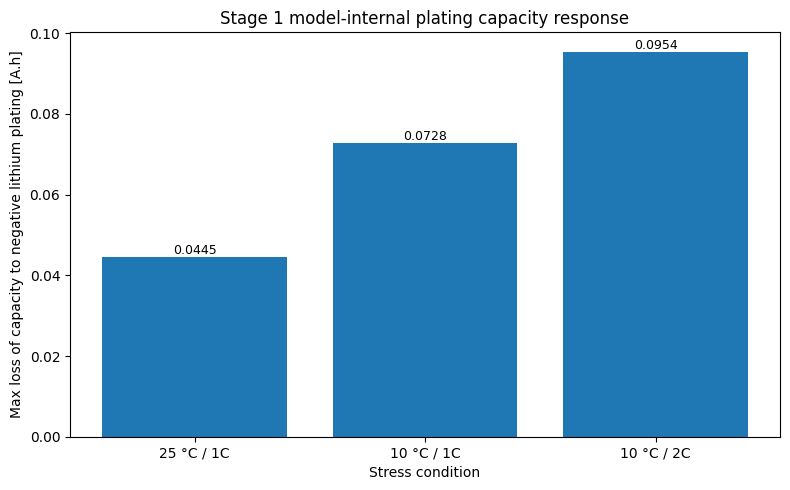

[OK] saved figure: docs/figures/plating_stage1_max_plating_capacity_by_stress.png

[OK] Capacity response table:


,matched_pair_id,stress_label,control_max_abs,plating_max_abs,plating_minus_control_max_abs,plating_final_value,control_final_value
0,pair_25C_1C,25 °C / 1C,0.0,0.044523,0.044523,0.000187,0.0
10,pair_10C_1C,10 °C / 1C,0.0,0.072795,0.072795,0.000386,0.0
20,pair_10C_2C,10 °C / 2C,0.0,0.095446,0.095446,0.000518,0.0



[BOUNDARY CHECKS]
[OK] No-plating controls remain zero for plating capacity.
[OK] Plating-enabled branches show non-zero plating capacity.
[OK] Max plating capacity increases with stress severity.
[OK] This is a model-internal Level 0 signal, not an external diagnostic fingerprint.


In [3]:
# Cell 6 — Plot maximum plating capacity by stress condition（绘制不同应力条件下最大析锂容量）

stress_order = ["pair_25C_1C", "pair_10C_1C", "pair_10C_2C"]
stress_labels = {
    "pair_25C_1C": "25 °C / 1C",
    "pair_10C_1C": "10 °C / 1C",
    "pair_10C_2C": "10 °C / 2C",
}

capacity_plot_df = capacity_summary_df.copy()
capacity_plot_df["stress_label"] = capacity_plot_df["matched_pair_id"].map(stress_labels)
capacity_plot_df["stress_order"] = capacity_plot_df["matched_pair_id"].map(
    {pair: i for i, pair in enumerate(stress_order)}
)
capacity_plot_df = capacity_plot_df.sort_values("stress_order")

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    capacity_plot_df["stress_label"],
    capacity_plot_df["plating_max_abs"],
)

ax.set_title("Stage 1 model-internal plating capacity response")
ax.set_xlabel("Stress condition")
ax.set_ylabel("Max loss of capacity to negative lithium plating [A.h]")

for idx, row in capacity_plot_df.iterrows():
    ax.text(
        row["stress_order"],
        row["plating_max_abs"],
        f"{row['plating_max_abs']:.4f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xticks(rotation=0)
plt.tight_layout()

fig_path = docs_fig_dir / "plating_stage1_max_plating_capacity_by_stress.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[OK] saved figure: {fig_path.relative_to(repo)}")

print("\n[OK] Capacity response table:")
display(
    capacity_plot_df[
        [
            "matched_pair_id",
            "stress_label",
            "control_max_abs",
            "plating_max_abs",
            "plating_minus_control_max_abs",
            "plating_final_value",
            "control_final_value",
        ]
    ]
)

# Audit checks
assert (capacity_plot_df["control_max_abs"] == 0).all(), (
    "No-plating controls must remain zero for plating capacity."
)

assert (capacity_plot_df["plating_max_abs"] > 0).all(), (
    "Plating-enabled branches must have non-zero plating capacity."
)

assert capacity_plot_df["plating_max_abs"].is_monotonic_increasing, (
    "Expected stress-dependent increase in max plating capacity was not observed."
)

print("\n[BOUNDARY CHECKS]")
print("[OK] No-plating controls remain zero for plating capacity.")
print("[OK] Plating-enabled branches show non-zero plating capacity.")
print("[OK] Max plating capacity increases with stress severity.")
print("[OK] This is a model-internal Level 0 signal, not an external diagnostic fingerprint.")

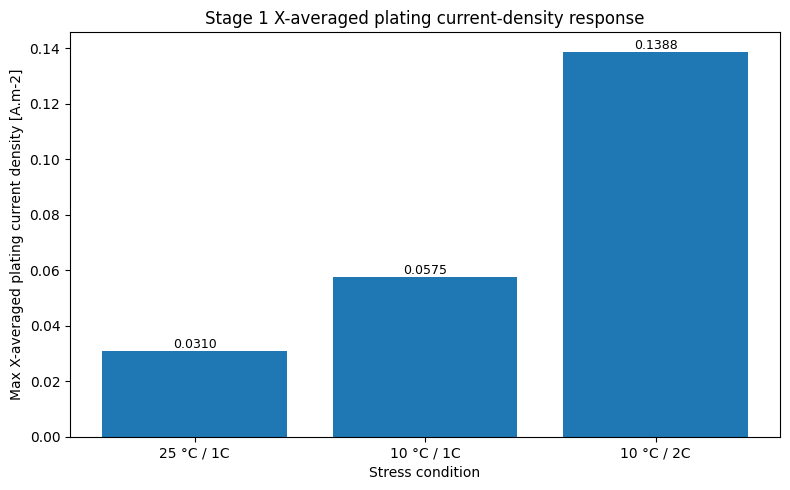

[OK] saved figure: docs/figures/plating_stage1_plating_current_density_by_stress.png

[OK] X-averaged plating current-density response table:


,matched_pair_id,stress_label,control_max_abs,plating_max_abs,plating_minus_control_max_abs,plating_final_value,control_final_value
6,pair_25C_1C,25 °C / 1C,0.0,0.030974,0.030974,-3.248450e-11,0.0
16,pair_10C_1C,10 °C / 1C,0.0,0.057522,0.057522,2.255052e-09,0.0
26,pair_10C_2C,10 °C / 2C,0.0,0.138783,0.138783,-6.172627e-10,0.0



[BOUNDARY CHECKS]
[OK] No-plating controls remain zero for X-averaged plating current density.
[OK] Plating-enabled branches show non-zero X-averaged plating current density.
[OK] X-averaged plating current density increases with stress severity.
[OK] This remains model-internal Level 0 evidence.


In [4]:
# Cell 7 — Plot X-averaged plating current density by stress condition（绘制不同应力条件下 X 平均析锂电流密度）

current_plot_df = xavg_current_summary_df.copy()
current_plot_df["stress_label"] = current_plot_df["matched_pair_id"].map(stress_labels)
current_plot_df["stress_order"] = current_plot_df["matched_pair_id"].map(
    {pair: i for i, pair in enumerate(stress_order)}
)
current_plot_df = current_plot_df.sort_values("stress_order")

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    current_plot_df["stress_label"],
    current_plot_df["plating_max_abs"],
)

ax.set_title("Stage 1 X-averaged plating current-density response")
ax.set_xlabel("Stress condition")
ax.set_ylabel("Max X-averaged plating current density [A.m-2]")

for idx, row in current_plot_df.iterrows():
    ax.text(
        row["stress_order"],
        row["plating_max_abs"],
        f"{row['plating_max_abs']:.4f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xticks(rotation=0)
plt.tight_layout()

fig_path = docs_fig_dir / "plating_stage1_plating_current_density_by_stress.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[OK] saved figure: {fig_path.relative_to(repo)}")

print("\n[OK] X-averaged plating current-density response table:")
display(
    current_plot_df[
        [
            "matched_pair_id",
            "stress_label",
            "control_max_abs",
            "plating_max_abs",
            "plating_minus_control_max_abs",
            "plating_final_value",
            "control_final_value",
        ]
    ]
)

# Audit checks
assert (current_plot_df["control_max_abs"] == 0).all(), (
    "No-plating controls must remain zero for x-averaged plating current density."
)

assert (current_plot_df["plating_max_abs"] > 0).all(), (
    "Plating-enabled branches must have non-zero x-averaged plating current density."
)

assert current_plot_df["plating_max_abs"].is_monotonic_increasing, (
    "Expected stress-dependent increase in x-averaged plating current density was not observed."
)

print("\n[BOUNDARY CHECKS]")
print("[OK] No-plating controls remain zero for X-averaged plating current density.")
print("[OK] Plating-enabled branches show non-zero X-averaged plating current density.")
print("[OK] X-averaged plating current density increases with stress severity.")
print("[OK] This remains model-internal Level 0 evidence.")

## 3. Maximum internal plating response versus final residual（最大内部析锂响应与最终残余）

This block compares the maximum model-internal plating response during the stress trajectory with the final residual value after the full charge / CV / rest / discharge / rest protocol.

This distinction is central for the next diagnostic stage.

If the maximum internal plating response is much larger than the final residual, then later external diagnostics such as C/25 V(Q), GITT-like finite-rest voltage, ICA, and DVA may observe only a weak residual fingerprint.

This does not mean plating did not occur.

It means:

- model-internal plating occurred during stress
- much of the plating-associated state was reversible or relaxed after the full protocol
- post-stress external diagnostic closure may be intrinsically weak

This block therefore defines an important boundary for Stage 2 interpretation.

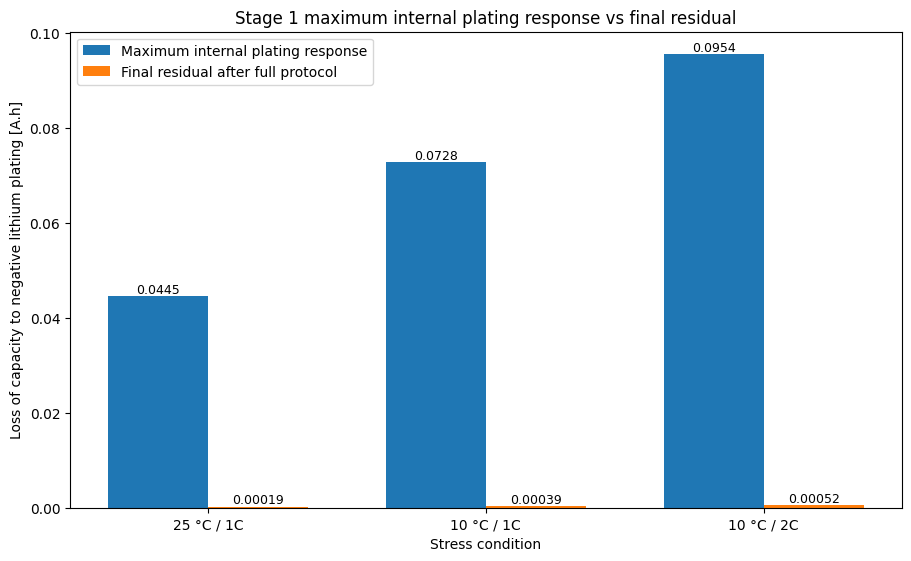

[OK] saved figure: docs/figures/plating_stage1_max_vs_final_residual.png

[OK] Maximum internal response versus final residual table:


,matched_pair_id,stress_label,plating_max_abs,plating_final_value,final_to_max_ratio,reversibility_indicator
0,pair_25C_1C,25 °C / 1C,0.044523,0.000187,0.004206,0.995794
10,pair_10C_1C,10 °C / 1C,0.072795,0.000386,0.005296,0.994704
20,pair_10C_2C,10 °C / 2C,0.095446,0.000518,0.005430,0.994570


[OK] saved summary table: docs/tables/plating_stage1_max_vs_final_residual_summary_v0_1.csv

[BOUNDARY CHECKS]
[OK] Maximum internal plating response is positive for all stress conditions.
[OK] Final residual is much smaller than maximum internal plating response.
[OK] Stage 2 may therefore observe weak post-stress external fingerprints.
[OK] Weak future external signal must not be interpreted as absence of model-internal plating.


In [6]:
# Cell 9 — Compare maximum internal plating response with final residual（比较最大内部析锂响应与最终残余）

residual_df = capacity_plot_df.copy()

residual_df["final_to_max_ratio"] = (
    residual_df["plating_final_value"].abs()
    / residual_df["plating_max_abs"].replace(0, np.nan)
)

residual_df["reversibility_indicator"] = 1.0 - residual_df["final_to_max_ratio"]

fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)

x = np.arange(len(residual_df))
width = 0.36

ax.bar(
    x - width / 2,
    residual_df["plating_max_abs"],
    width,
    label="Maximum internal plating response",
)

ax.bar(
    x + width / 2,
    residual_df["plating_final_value"].abs(),
    width,
    label="Final residual after full protocol",
)

ax.set_title("Stage 1 maximum internal plating response vs final residual")
ax.set_xlabel("Stress condition")
ax.set_ylabel("Loss of capacity to negative lithium plating [A.h]")
ax.set_xticks(x)
ax.set_xticklabels(residual_df["stress_label"])
ax.legend(loc="upper left")

for i, row in residual_df.iterrows():
    ax.text(
        row["stress_order"] - width / 2,
        row["plating_max_abs"],
        f"{row['plating_max_abs']:.4f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
    ax.text(
        row["stress_order"] + width / 2,
        abs(row["plating_final_value"]),
        f"{abs(row['plating_final_value']):.5f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

fig_path = docs_fig_dir / "plating_stage1_max_vs_final_residual.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[OK] saved figure: {fig_path.relative_to(repo)}")

print("\n[OK] Maximum internal response versus final residual table:")
display(
    residual_df[
        [
            "matched_pair_id",
            "stress_label",
            "plating_max_abs",
            "plating_final_value",
            "final_to_max_ratio",
            "reversibility_indicator",
        ]
    ]
)

# Save a summary table for documentation
residual_summary_path = docs_table_dir / "plating_stage1_max_vs_final_residual_summary_v0_1.csv"
residual_df[
    [
        "matched_pair_id",
        "stress_label",
        "plating_max_abs",
        "plating_final_value",
        "final_to_max_ratio",
        "reversibility_indicator",
    ]
].to_csv(residual_summary_path, index=False)

print(f"[OK] saved summary table: {residual_summary_path.relative_to(repo)}")

# Audit checks
assert (residual_df["plating_max_abs"] > 0).all(), (
    "Maximum internal plating response must be positive."
)

assert (residual_df["final_to_max_ratio"] < 0.02).all(), (
    "Final residual is expected to remain much smaller than maximum internal response."
)

print("\n[BOUNDARY CHECKS]")
print("[OK] Maximum internal plating response is positive for all stress conditions.")
print("[OK] Final residual is much smaller than maximum internal plating response.")
print("[OK] Stage 2 may therefore observe weak post-stress external fingerprints.")
print("[OK] Weak future external signal must not be interpreted as absence of model-internal plating.")

## 4. Matched protocol delta audit（匹配协议差异审计）

This block checks whether the plating-enabled and no-plating control branches remain protocol-comparable.

The key question is not whether the two branches are numerically identical, but whether the matched protocol remains close enough that direct plating-state differences can be interpreted under matched-control logic.

Audited quantities:

- duration difference
- charged capacity difference
- discharged capacity difference
- throughput difference
- final voltage difference

This audit is not used to infer external diagnostic fingerprints.

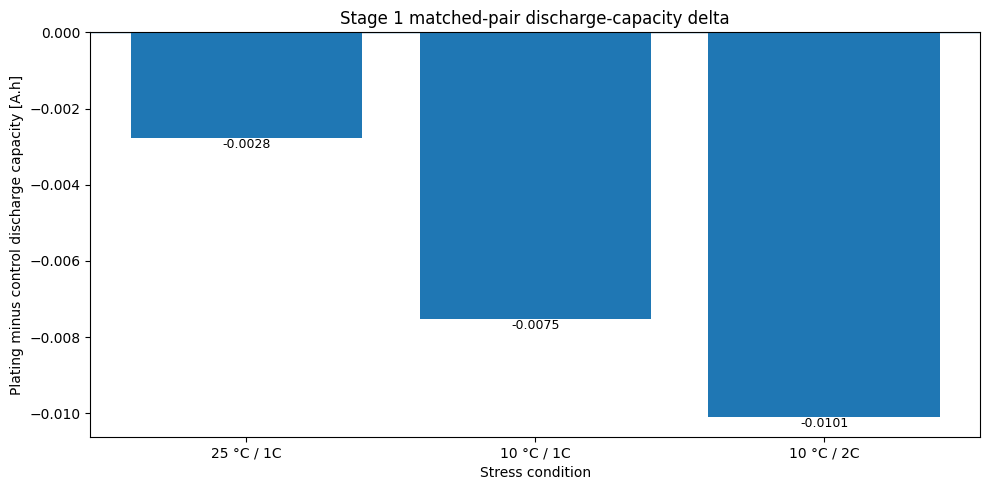

[OK] saved figure: docs/figures/plating_stage1_matched_protocol_delta.png

[OK] Matched protocol delta table:


,matched_pair_id,metric,control_value,plating_value,plating_minus_control,stress_label,stress_order
5,pair_25C_1C,U_end_V,2.768019,2.768019,2.734041e-07,25 °C / 1C,0
11,pair_10C_1C,U_end_V,2.910554,2.910561,7.486731e-06,10 °C / 1C,1
17,pair_10C_2C,U_end_V,2.910552,2.910562,1.023215e-05,10 °C / 2C,2
1,pair_25C_1C,charge_Ah,4.783172,4.780597,-2.574948e-03,25 °C / 1C,0
7,pair_10C_1C,charge_Ah,4.725713,4.718561,-7.151307e-03,10 °C / 1C,1
13,pair_10C_2C,charge_Ah,4.723349,4.713701,-9.648069e-03,10 °C / 2C,2
2,pair_25C_1C,discharge_Ah,4.978101,4.975338,-2.762808e-03,25 °C / 1C,0
8,pair_10C_1C,discharge_Ah,4.880210,4.872680,-7.529941e-03,10 °C / 1C,1
14,pair_10C_2C,discharge_Ah,4.877728,4.867616,-1.011186e-02,10 °C / 2C,2
0,pair_25C_1C,duration_min,396.636077,396.188655,-4.474214e-01,25 °C / 1C,0


[OK] saved protocol delta table: docs/tables/plating_stage1_matched_protocol_delta_v0_1.csv

[BOUNDARY CHECKS]
[OK] Final voltage mismatch remains below 1 mV across matched pairs.
[OK] Discharge-capacity deltas remain below 0.02 Ah across matched pairs.
[OK] Matched-pair protocol comparability is acceptable for Level 0 audit.
[OK] These deltas do not establish external diagnostic fingerprint closure.


In [7]:
# Cell 11 — Plot matched protocol deltas（绘制匹配协议差异）

protocol_metrics = [
    "duration_min",
    "charge_Ah",
    "discharge_Ah",
    "throughput_Ah",
    "net_charge_Ah",
    "U_end_V",
]

protocol_delta_df = stress_summary_df[
    stress_summary_df["metric"].isin(protocol_metrics)
].copy()

protocol_delta_df["stress_label"] = protocol_delta_df["matched_pair_id"].map(stress_labels)
protocol_delta_df["stress_order"] = protocol_delta_df["matched_pair_id"].map(
    {pair: i for i, pair in enumerate(stress_order)}
)
protocol_delta_df = protocol_delta_df.sort_values(["metric", "stress_order"])

fig, ax = plt.subplots(figsize=(10, 5))

plot_metric = "discharge_Ah"
plot_df = protocol_delta_df[protocol_delta_df["metric"] == plot_metric].copy()

ax.bar(
    plot_df["stress_label"],
    plot_df["plating_minus_control"],
)

ax.axhline(0, linewidth=1)
ax.set_title("Stage 1 matched-pair discharge-capacity delta")
ax.set_xlabel("Stress condition")
ax.set_ylabel("Plating minus control discharge capacity [A.h]")

for i, row in enumerate(plot_df.itertuples()):
    ax.text(
        i,
        row.plating_minus_control,
        f"{row.plating_minus_control:.4f}",
        ha="center",
        va="bottom" if row.plating_minus_control >= 0 else "top",
        fontsize=9,
    )

plt.tight_layout()

fig_path = docs_fig_dir / "plating_stage1_matched_protocol_delta.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[OK] saved figure: {fig_path.relative_to(repo)}")

print("\n[OK] Matched protocol delta table:")
display(protocol_delta_df)

# Save documentation table
protocol_delta_path = docs_table_dir / "plating_stage1_matched_protocol_delta_v0_1.csv"
protocol_delta_df.to_csv(protocol_delta_path, index=False)

print(f"[OK] saved protocol delta table: {protocol_delta_path.relative_to(repo)}")

# Audit checks
u_end_delta = protocol_delta_df[protocol_delta_df["metric"] == "U_end_V"]["plating_minus_control"].abs()
discharge_delta = protocol_delta_df[protocol_delta_df["metric"] == "discharge_Ah"]["plating_minus_control"].abs()

assert (u_end_delta < 1e-3).all(), (
    "Final voltage mismatch should remain below 1 mV for matched-pair comparability."
)

assert (discharge_delta < 0.02).all(), (
    "Matched discharge-capacity deltas should remain below 0.02 Ah in this Stage 1 audit."
)

print("\n[BOUNDARY CHECKS]")
print("[OK] Final voltage mismatch remains below 1 mV across matched pairs.")
print("[OK] Discharge-capacity deltas remain below 0.02 Ah across matched pairs.")
print("[OK] Matched-pair protocol comparability is acceptable for Level 0 audit.")
print("[OK] These deltas do not establish external diagnostic fingerprint closure.")

In [8]:
# Cell 12 — Build Level 0 summary table（构建 Level 0 总结表）

level0_summary_rows = []

for _, row in capacity_plot_df.iterrows():
    pair_id = row["matched_pair_id"]
    stress_label = row["stress_label"]

    current_row = current_plot_df[current_plot_df["matched_pair_id"] == pair_id].iloc[0]
    residual_row = residual_df[residual_df["matched_pair_id"] == pair_id].iloc[0]

    level0_summary_rows.append({
        "matched_pair_id": pair_id,
        "stress_label": stress_label,
        "control_plating_capacity_max_Ah": row["control_max_abs"],
        "plating_capacity_max_Ah": row["plating_max_abs"],
        "plating_capacity_final_Ah": row["plating_final_value"],
        "final_to_max_ratio": residual_row["final_to_max_ratio"],
        "reversibility_indicator": residual_row["reversibility_indicator"],
        "xavg_plating_current_density_max_A_m2": current_row["plating_max_abs"],
        "control_xavg_plating_current_density_max_A_m2": current_row["control_max_abs"],
        "control_clean": bool(
            (row["control_max_abs"] == 0)
            and (current_row["control_max_abs"] == 0)
        ),
        "internal_plating_signal_detected": bool(
            (row["plating_max_abs"] > 0)
            and (current_row["plating_max_abs"] > 0)
        ),
        "level0_claim_status": "supported",
        "external_diagnostic_status": "not_tested",
        "correct_conclusion_wording": (
            "Model-internal lithium-plating state observability is supported for this matched pair; "
            "external diagnostic fingerprint closure remains untested."
        ),
    })

level0_summary_df = pd.DataFrame(level0_summary_rows)

level0_summary_path = docs_table_dir / "plating_stage1_level0_summary_v0_1.csv"
level0_summary_df.to_csv(level0_summary_path, index=False)

print(f"[OK] saved Level 0 summary table: {level0_summary_path.relative_to(repo)}")

print("\n[OK] Level 0 summary table:")
display(level0_summary_df)

# Audit checks
assert level0_summary_df["control_clean"].all(), (
    "All no-plating controls must remain clean."
)

assert level0_summary_df["internal_plating_signal_detected"].all(), (
    "All plating-enabled branches must show internal plating signal."
)

assert level0_summary_df["plating_capacity_max_Ah"].is_monotonic_increasing, (
    "Internal plating capacity should increase with stress severity."
)

assert level0_summary_df["xavg_plating_current_density_max_A_m2"].is_monotonic_increasing, (
    "X-averaged plating current density should increase with stress severity."
)

assert (level0_summary_df["external_diagnostic_status"] == "not_tested").all(), (
    "External diagnostic status must remain not_tested in Notebook 29."
)

print("\n[BOUNDARY CHECKS]")
print("[OK] All no-plating controls are clean.")
print("[OK] All plating-enabled branches show model-internal plating signal.")
print("[OK] Internal plating capacity increases with stress severity.")
print("[OK] X-averaged plating current density increases with stress severity.")
print("[OK] External diagnostic fingerprint closure remains not tested.")
print("[OK] Notebook 29 supports Level 0 only.")

[OK] saved Level 0 summary table: docs/tables/plating_stage1_level0_summary_v0_1.csv

[OK] Level 0 summary table:


,matched_pair_id,stress_label,control_plating_capacity_max_Ah,plating_capacity_max_Ah,plating_capacity_final_Ah,final_to_max_ratio,reversibility_indicator,xavg_plating_current_density_max_A_m2,control_xavg_plating_current_density_max_A_m2,control_clean,internal_plating_signal_detected,level0_claim_status,external_diagnostic_status,correct_conclusion_wording
0,pair_25C_1C,25 °C / 1C,0.0,0.044523,0.000187,0.004206,0.995794,0.030974,0.0,True,True,supported,not_tested,Model-internal lithium-plating state observabi...
1,pair_10C_1C,10 °C / 1C,0.0,0.072795,0.000386,0.005296,0.994704,0.057522,0.0,True,True,supported,not_tested,Model-internal lithium-plating state observabi...
2,pair_10C_2C,10 °C / 2C,0.0,0.095446,0.000518,0.005430,0.994570,0.138783,0.0,True,True,supported,not_tested,Model-internal lithium-plating state observabi...



[BOUNDARY CHECKS]
[OK] All no-plating controls are clean.
[OK] All plating-enabled branches show model-internal plating signal.
[OK] Internal plating capacity increases with stress severity.
[OK] X-averaged plating current density increases with stress severity.
[OK] External diagnostic fingerprint closure remains not tested.
[OK] Notebook 29 supports Level 0 only.


## Final closure（最终闭合）

### Key findings

This notebook audited the Stage 1 process-isolated lithium-plating stress-state generation outputs.

No PyBaMM simulations were executed in this notebook.

The audit used the completed Stage 1 matched-check tables:

- `docs/tables/plating_external_stage1_all_pairs_stress_summary_matched_check.csv`
- `docs/tables/plating_external_stage1_all_pairs_direct_plating_matched_check.csv`

The notebook generated documentation-ready figures:

- `docs/figures/plating_stage1_max_plating_capacity_by_stress.png`
- `docs/figures/plating_stage1_plating_current_density_by_stress.png`
- `docs/figures/plating_stage1_max_vs_final_residual.png`
- `docs/figures/plating_stage1_matched_protocol_delta.png`

The notebook generated documentation-ready tables:

- `docs/tables/plating_stage1_max_vs_final_residual_summary_v0_1.csv`
- `docs/tables/plating_stage1_matched_protocol_delta_v0_1.csv`
- `docs/tables/plating_stage1_level0_summary_v0_1.csv`

### Supported conclusions

Stage 1 successfully supports Level 0 evidence:

> model-internal lithium-plating state observability.

The no-plating controls remained clean:

- direct plating capacity = zero
- X-averaged plating current density = zero

The plating-enabled branches showed non-zero model-internal plating variables across all matched pairs.

The maximum loss of capacity to negative lithium plating increased with stress severity:

| Stress condition | Maximum internal plating capacity |
|---|---:|
| 25 °C / 1C | approximately 0.0445 Ah |
| 10 °C / 1C | approximately 0.0728 Ah |
| 10 °C / 2C | approximately 0.0954 Ah |

The maximum X-averaged negative-electrode plating interfacial current density also increased with stress severity:

| Stress condition | Maximum X-averaged plating current density |
|---|---:|
| 25 °C / 1C | approximately 0.0310 A m⁻² |
| 10 °C / 1C | approximately 0.0575 A m⁻² |
| 10 °C / 2C | approximately 0.1388 A m⁻² |

### Partially supported conclusions

The matched-pair protocol comparability is acceptable for Level 0 audit.

Final voltage mismatch remained below 1 mV across matched pairs.

Matched discharge-capacity deltas remained below 0.02 Ah across matched pairs.

These deltas are acceptable for auditing model-internal plating separation, but they do not establish external diagnostic fingerprint closure.

### Unsupported / deferred claims

External lithium-plating diagnostic fingerprint closure remains untested.

This notebook does not support:

- C/25 V(Q) diagnostic validity
- GITT-like finite-rest voltage diagnostic validity
- ICA feature validity
- DVA feature validity
- Level 1 matched external signal
- Level 2 candidate external plating fingerprint
- Level 3 fitting-target qualification

### Execution or protocol boundaries

This notebook only reads CSV outputs from the Stage 1 process-isolated runner.

It does not hold PyBaMM Solution objects in notebook memory.

The Stage 1 results show that maximum internal plating response is much larger than final residual plating capacity after the full charge / CV / rest / discharge / rest protocol.

This means future post-stress external diagnostic signals may be weak. A weak future C/25, GITT-like, ICA, or DVA signal must not be interpreted as absence of model-internal lithium plating.

### Correct conclusion wording

The correct conclusion of this notebook is:

Stage 1 process-isolated stress-state generation supports clean model-internal lithium-plating state observability across all registered matched pairs. No-plating controls remain clean, while plating-enabled branches show stress-dependent internal plating signals. External diagnostic fingerprint closure remains deferred to later diagnostic notebooks.

### Next step

The next notebook should be:

`notebooks/30_lithium_plating_c25_vq_diagnostic_audit.ipynb`

Notebook 30 should audit C/25 central-window V(Q) as the first external diagnostic layer.

The execution design should remain process-isolated:

- JupyterLab may start external scripts through subprocess
- PyBaMM simulations should run in external Python processes
- the notebook should read exported CSV files and generate plots
- no large live PyBaMM Solution objects should be retained inside the notebook